# Overview

In [19]:
import pandas as pd

df = pd.read_csv("../data/train.csv").drop('id', axis=1)
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [20]:
accepted_percentage = (df['loan_status'].sum() / len(df)) * 100
print(f"Accepted loan percentage: {accepted_percentage:.2f}%")
df.dtypes

Accepted loan percentage: 14.24%


person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object

# Features analysis

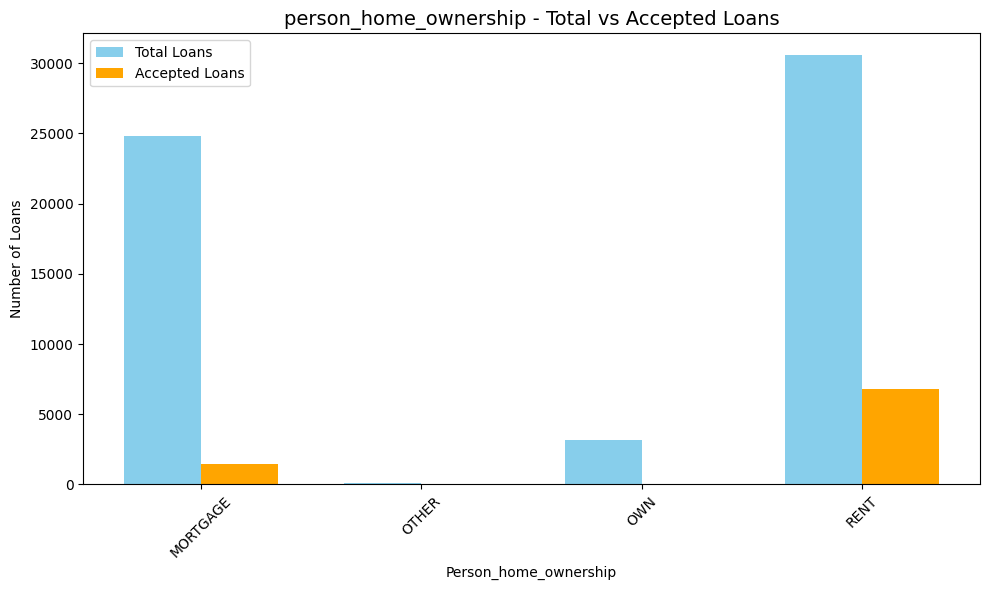

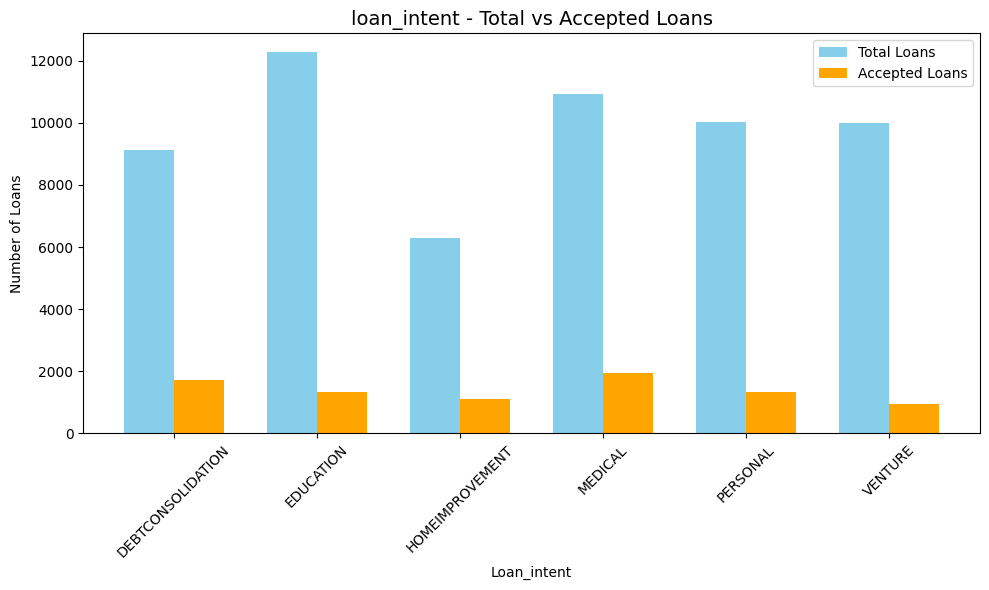

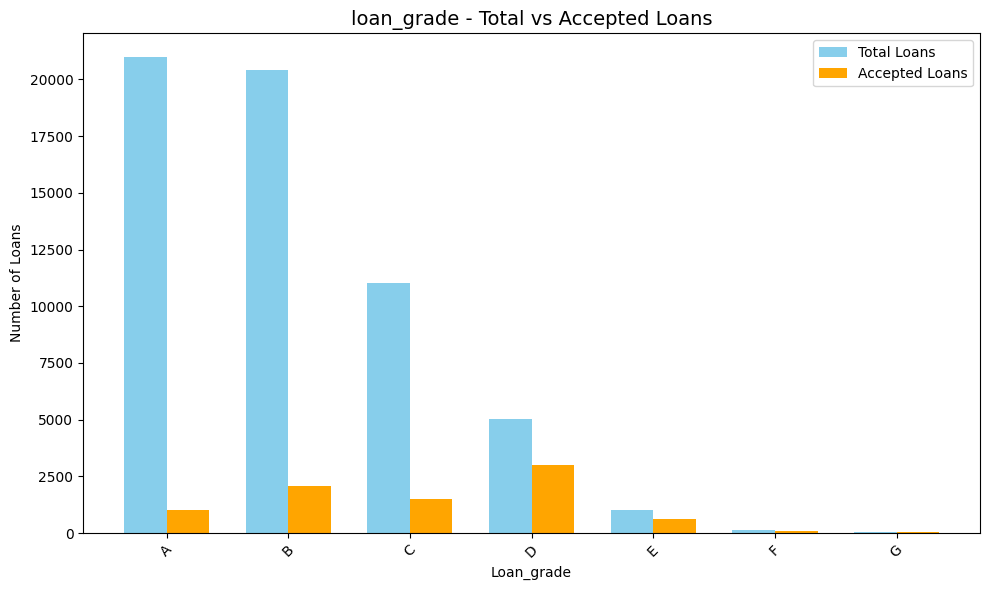

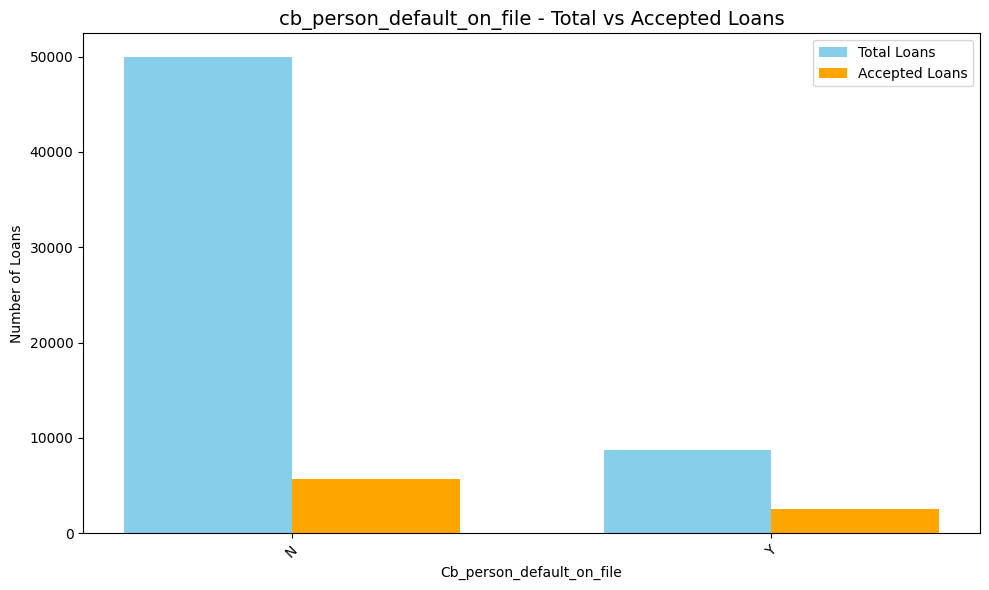

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_categorical_bar(df, column, title=None):
    """
    Plots a grouped bar chart for a categorical column:
    - Total loans per category
    - Accepted loans per category

    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The categorical column to visualize.
        title (str, optional): Custom chart title.
    """
    # Total and accepted loan counts per category
    total_counts = df[column].value_counts().sort_index()
    accepted_counts = df[df['loan_status'] == True][column].value_counts().sort_index()

    # Align indices to ensure matching categories
    categories = sorted(total_counts.index)
    total = [total_counts.get(cat, 0) for cat in categories]
    accepted = [accepted_counts.get(cat, 0) for cat in categories]

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, total, width, label='Total Loans', color='skyblue')
    bars2 = ax.bar(x + width/2, accepted, width, label='Accepted Loans', color='orange')

    # Labels and formatting
    ax.set_ylabel('Number of Loans')
    ax.set_xlabel(column.capitalize())
    ax.set_title(title or f'{column} - Total vs Accepted Loans', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Apply to all object-type columns
for col in df.columns:
    if df[col].dtype == object:
        plot_categorical_bar(df, col)


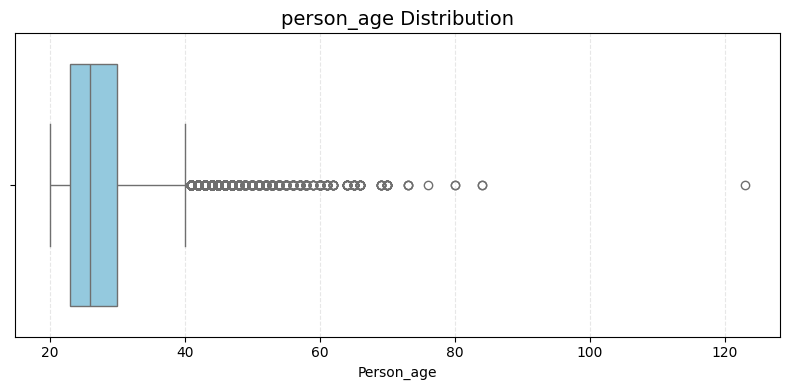

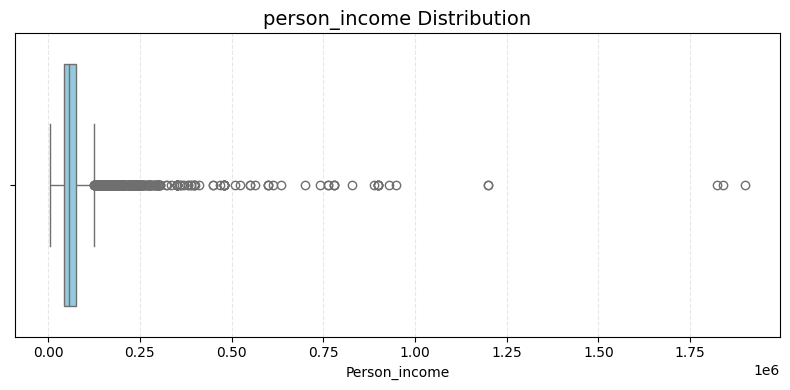

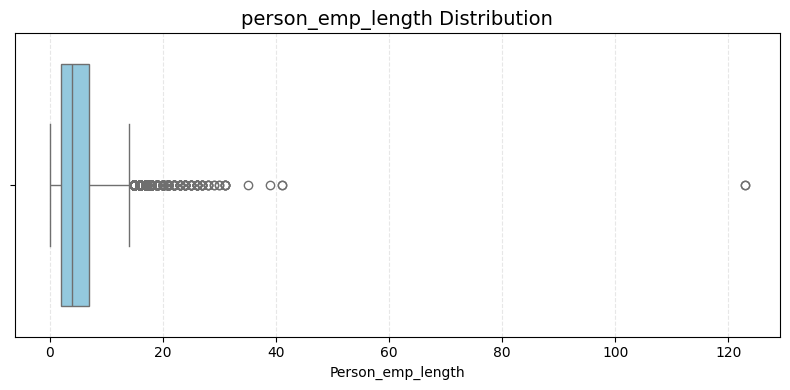

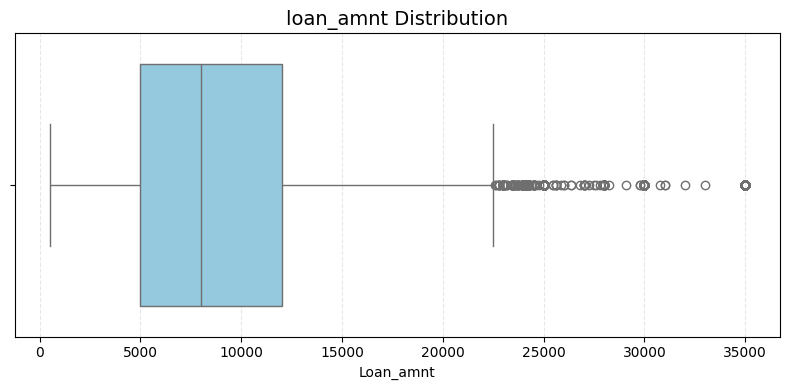

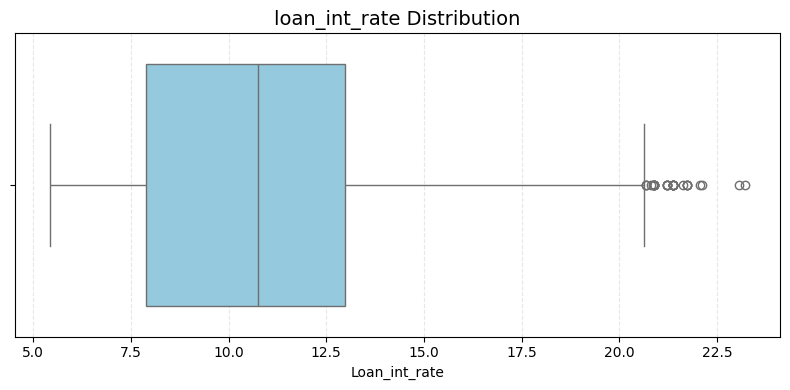

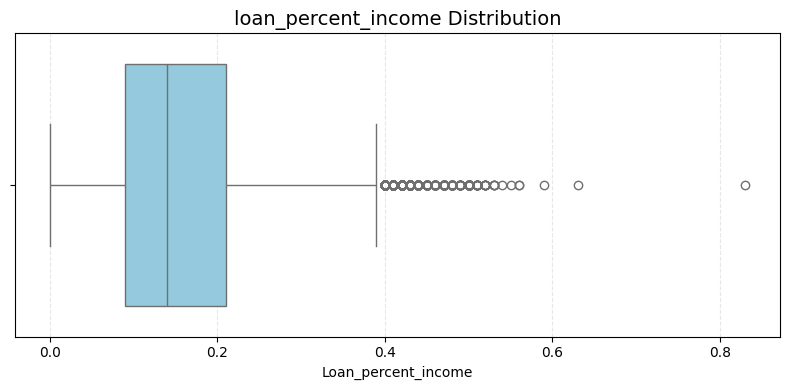

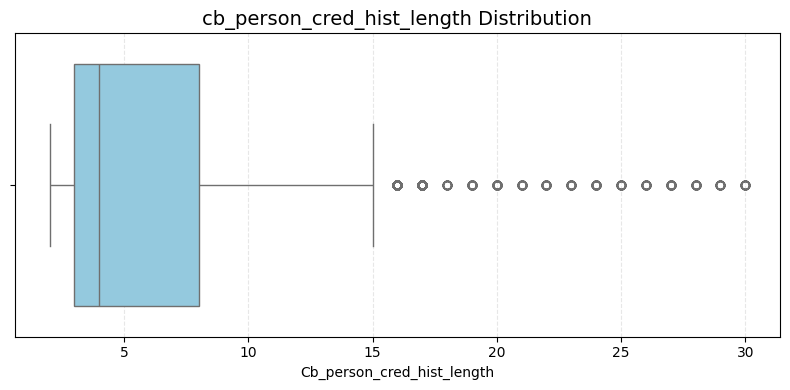

In [22]:
import seaborn as sns

def plot_numerical_boxplot(df, column, title=None):
    """
    Displays a clean boxplot for a numerical column in a DataFrame.
    
    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The column name (numerical) to visualize.
        title (str, optional): Title for the plot.
    """
    if not pd.api.types.is_numeric_dtype(df[column]):
        raise ValueError(f"Column '{column}' must be numerical.")
    
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column], color='skyblue')
    
    plt.title(title or f"{column} Distribution", fontsize=14)
    plt.xlabel(column.capitalize())
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

for col in list(df.columns):
    if df[col].dtype != object and col != 'loan_status':
        plot_numerical_boxplot(df, col, title=None)

# Outliers spotting

In [23]:
df.query('person_age > 100')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
47336,123,36000,MORTGAGE,7.0,PERSONAL,B,6700,10.75,0.18,N,4,0


In [24]:
df.query('person_income > 500000')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
2093,32,1200000,RENT,2.0,PERSONAL,A,10000,7.51,0.01,N,9,0
2298,37,780000,RENT,9.0,HOMEIMPROVEMENT,B,7500,12.18,0.01,N,7,0
4301,35,522000,RENT,2.0,DEBTCONSOLIDATION,A,10000,7.49,0.02,N,9,0
8151,29,600000,MORTGAGE,14.0,DEBTCONSOLIDATION,A,7000,8.49,0.01,N,8,0
11422,29,948000,OWN,11.0,PERSONAL,B,4000,11.83,0.04,N,5,0
11668,34,550000,MORTGAGE,12.0,EDUCATION,A,10400,7.43,0.02,N,10,0
12404,25,1839784,RENT,0.0,VENTURE,A,8000,8.00,0.04,N,3,0
12610,30,510000,MORTGAGE,2.0,PERSONAL,B,1800,9.01,0.04,N,9,0
12925,30,636000,MORTGAGE,2.0,DEBTCONSOLIDATION,B,20000,11.48,0.03,N,5,0
17387,22,1900000,MORTGAGE,6.0,EDUCATION,D,1500,15.62,0.00,Y,3,0


In [25]:
df.query('person_age < person_emp_length')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
41079,28,60350,MORTGAGE,123.0,MEDICAL,D,25000,15.95,0.35,Y,6,1
49252,21,192000,MORTGAGE,123.0,VENTURE,B,20000,11.49,0.10,N,2,0


In [26]:
df = df.query('person_age < 100 & person_income < 500000 & person_age > person_emp_length')

# Correlation map

/var/folders/51/wp8p35r53jb_1gftrtgfd5kw0000gn/T/ipykernel_2714/2084253971.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['loan_grade_numeric'] = df['loan_grade'].map(grade_mapping)


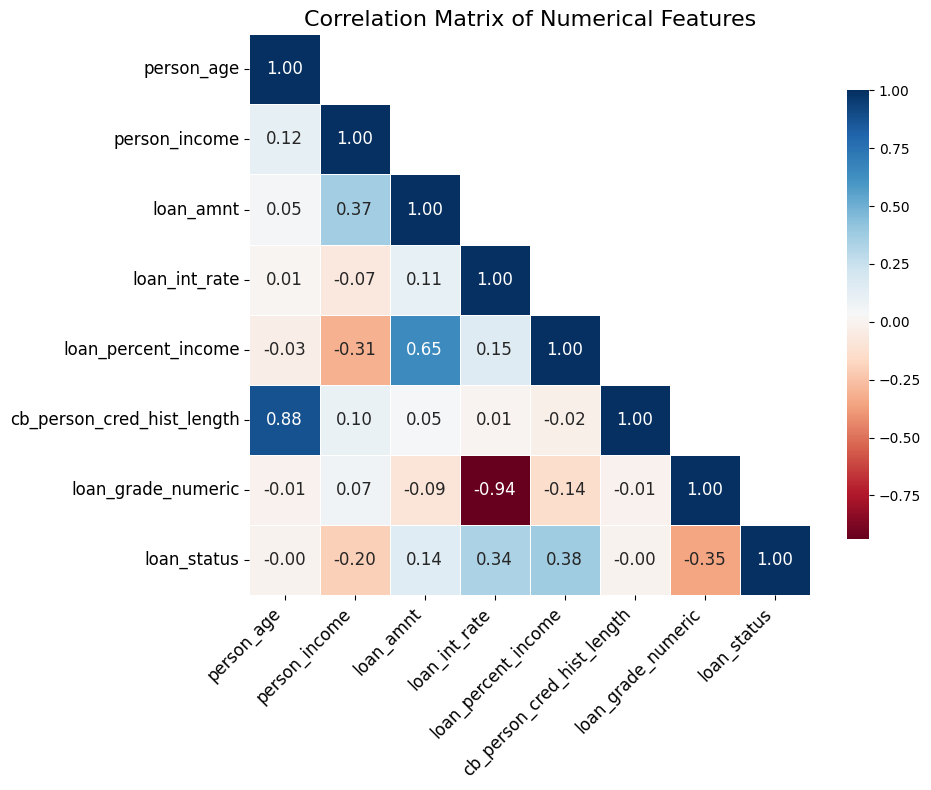

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Creates column loan_grade_numeric A->6, B->5...G->1
grade_mapping = {
    'A': 6,
    'B': 5,
    'C': 4,
    'D': 3,
    'F': 2,
    'G': 1
}

df['loan_grade_numeric'] = df['loan_grade'].map(grade_mapping)

# Create correlation matrix
numerical_features = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
                      'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade_numeric', 'loan_status']
corr_matrix = df[numerical_features].corr()

# Create a mask to only show lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), 1)

# Set up the plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap="RdBu", 
            square=True,
            linewidths=0.5,
            annot_kws={"size": 12},
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


# Dimension reduction

In [28]:
# the loan grade is -94% correlated with the loan interest rate so we remove the grade an keep interst rate (more precision since it is float)
df = df.drop(['loan_grade','loan_grade_numeric'], axis = 1)

# Maybe remove loan history length sinci it is 88% correlated with age ?

In [29]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_amnt', 'loan_int_rate',
       'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

# Encoding

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identification des données numériques et catégorielles (pas de données ordinales car loan grade a été retiré)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('loan_status')
cat_cols = ['loan_intent','cb_person_default_on_file','person_home_ownership']

# Normalisation des données numériques
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# One-hot encoding pour les données catégorielles
ohe_pipeline = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='error', sparse_output=False))
])

#Définition du transformeur
col_trans = ColumnTransformer(transformers=[
    ('num_p', num_pipeline, num_cols), 
    ('ohe_p', ohe_pipeline, cat_cols)
    ],
    remainder='passthrough', # Conserve les colonnes non spécifiées
    n_jobs=-1) # Accélère le traitement avec plusieurs cœurs

#Définition d'un pipeline global qui intègre toutes les transformations définies sur les colonnes
pipeline = Pipeline(steps=[
    ('preprocessing', col_trans)
])

num_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

# Models training

In [31]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...
58640,34,120000,MORTGAGE,5.0,EDUCATION,25000,15.95,0.21,Y,10,0
58641,28,28800,RENT,0.0,MEDICAL,10000,12.73,0.35,N,8,1
58642,23,44000,RENT,7.0,EDUCATION,6800,16.00,0.15,N,2,1
58643,22,30000,RENT,2.0,EDUCATION,5000,8.90,0.17,N,3,0


In [32]:
from sklearn.model_selection import train_test_split

# Séparation des données d'entraînement
X = df.drop('loan_status', axis=1) # les caractéristiques (features)
y = df['loan_status'] # la variable cible

In [33]:
# Application du prétraitement défini dans le pipeline global aux données
X_preprocessed = pipeline.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=25)

In [34]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [35]:
lr.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred_lr = lr.predict(X_test)
mean_squared_error(y_test, y_pred_lr)

np.float64(0.09101756706522848)